In [1]:
import sys
from pathlib import Path

sys.path.append(f"{Path().absolute().parent}")

In [2]:
from __future__ import annotations

from MRO_library import *
import plots
from radp.digital_twin.utils.gis_tools import GISTools

### Data Preprocessing

In [3]:
ue_data = pd.read_csv('data/sim_data/UE_data_20UE_100ticks.csv')
# ue_data = pd.read_csv("data/sim_data/100UE_500Ticks.csv")
# ue_data = ue_data.rename(
#    columns={"lon": "longitude", "lat": "latitude"}
#)  # Delete Later

ue_data

,mock_ue_id,longitude,latitude,tick
0,0,-22.625309,59.806764,0
1,1,119.764151,54.857584,0
2,2,72.095437,-20.253892,0
3,3,-67.548009,-38.100941,0
4,4,59.867089,-83.103930,0
...,...,...,...,...
1995,15,45.564260,42.609846,99
1996,16,132.457280,17.241235,99
1997,17,-101.217659,72.295988,99
1998,18,-16.480045,-26.656397,99


In [4]:
topology = pd.read_csv("data/sim_data/topology.csv")

topology.loc[topology["cell_id"] == "cell_1", "cell_lat"] = -90
topology.loc[topology["cell_id"] == "cell_2", "cell_lat"] = 0
topology.loc[topology["cell_id"] == "cell_3", "cell_lat"] = 90

topology.loc[topology["cell_id"] == "cell_1", "cell_lon"] = -180
topology.loc[topology["cell_id"] == "cell_2", "cell_lon"] = 0
topology.loc[topology["cell_id"] == "cell_3", "cell_lon"] = 180

topology.loc[topology["cell_id"] == "cell_1", "cell_carrier_freq_mhz"] = 1500
topology.loc[topology["cell_id"] == "cell_2", "cell_carrier_freq_mhz"] = 1500
topology.loc[topology["cell_id"] == "cell_3", "cell_carrier_freq_mhz"] = 1800

topology

,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz
0,-90.0,-180.0,cell_1,0,1500
1,0.0,0.0,cell_2,120,1500
2,90.0,180.0,cell_3,240,1800


In [5]:
data = concatenate_ue_to_topology(ue_data, topology)
data = connect_ue_to_all_cells(data, topology)

In [6]:
# Calculating distance and received power
data["distance_km"] = data.apply(
    lambda row: GISTools.get_log_distance(
        row["latitude"], row["longitude"], row["cell_lat"], row["cell_lon"]
    ),
    axis=1,
)
data["cell_rxpower_dbm"] = data.apply(
    lambda row: calculate_received_power(
        row["distance_km"], row["cell_carrier_freq_mhz"]
    ),
    axis=1,
)
# Rename Mock UE ID to UE ID for consistency
data = data.rename(columns={"mock_ue_id": "ue_id"})
data["ue_id"] = data["ue_id"].astype(int)
topology["cell_id"] = topology["cell_id"].str.replace("cell_", "").astype(int)
data["cell_id"] = data["cell_id"].str.extract("(\d+)").astype(int)
data = data.rename(columns={"latitude": "loc_y", "longitude": "loc_x"})
data["relative_bearing"] = data.apply(
    lambda row: GISTools.get_relative_bearing(
        row["cell_az_deg"], row["cell_lat"], row["cell_lon"], row["loc_y"], row["loc_y"]
    ),
    axis=1,
)
# data = data.rename(columns={'cell_rxpower_dbm': 'rsrp_dbm'})
data = add_sinr_column(data)

### Perform Attachment w/ Hyst & TTT

In [7]:
data.columns

Index(['ue_id', 'loc_x', 'loc_y', 'tick', 'cell_lat', 'cell_lon', 'cell_id',
       'cell_az_deg', 'cell_carrier_freq_mhz', 'distance_km',
       'cell_rxpower_dbm', 'relative_bearing', 'sinr_db'],
      dtype='object')

#### HyperParameters

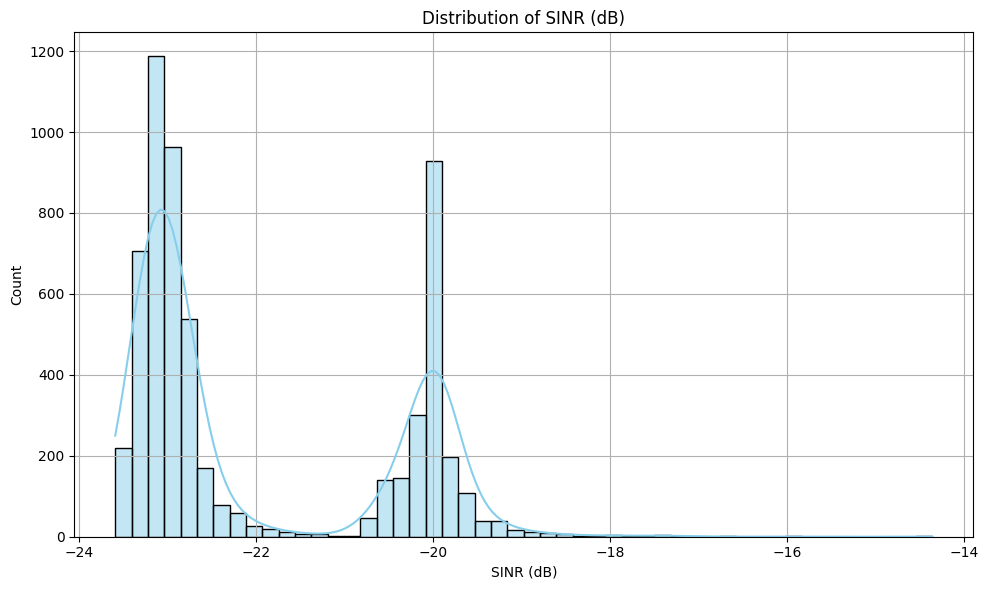

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data["sinr_db"], bins=50, kde=True, color='skyblue', edgecolor='black')
plt.title("Distribution of SINR (dB)")
plt.xlabel("SINR (dB)")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
hyst = 0.25  # 0<hyst
ttt = 5  # 2<ttt< total ticks
rlf_threshold = -23

In [10]:
attached_df = perform_attachment_hyst_ttt(data, hyst, ttt, rlf_threshold)

In [11]:
attached_df

,ue_id,loc_x,loc_y,tick,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz,distance_km,cell_rxpower_dbm,relative_bearing,sinr_db
1,0.0,-22.625309,59.806764,0.0,0.0,0.0,2.0,120.0,1500.0,15.752768,-96.918963,266.698642,-22.759301
4,1.0,119.764151,54.857584,0.0,0.0,0.0,2.0,120.0,1500.0,16.289273,-97.209859,269.925194,-22.902914
6,2.0,72.095437,-20.253892,0.0,-90.0,-180.0,1.0,0.0,1500.0,15.865016,-96.980635,159.746108,-19.923253
9,3.0,-67.548009,-38.100941,0.0,-90.0,-180.0,1.0,0.0,1500.0,15.569455,-96.817293,141.899059,-22.824816
12,4.0,59.867089,-83.103930,0.0,-90.0,-180.0,1.0,0.0,1500.0,13.551107,-95.611321,96.896070,-21.892206
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,15.0,45.564260,42.609846,99.0,-90.0,-180.0,1.0,0.0,1500.0,16.507565,-97.325486,222.609846,-20.303425
16,16.0,132.457280,17.241235,99.0,-90.0,-180.0,1.0,0.0,1500.0,16.295235,-97.213038,197.241235,-20.178436
17,17.0,-101.217659,72.295988,99.0,-90.0,-180.0,1.0,0.0,1500.0,16.709576,-97.431134,252.295988,-19.496643
18,18.0,-16.480045,-26.656397,99.0,0.0,0.0,2.0,120.0,1500.0,15.054748,-96.525295,101.787576,-22.473263


In [12]:
print(f"Switches: {count_switches(attached_df)}, RLF: {count_rlf(attached_df)}")
print(f"MRO Score: {calculate_mro_metric(attached_df)}")

Switches: 39, RLF: 0
MRO Score: 98.05


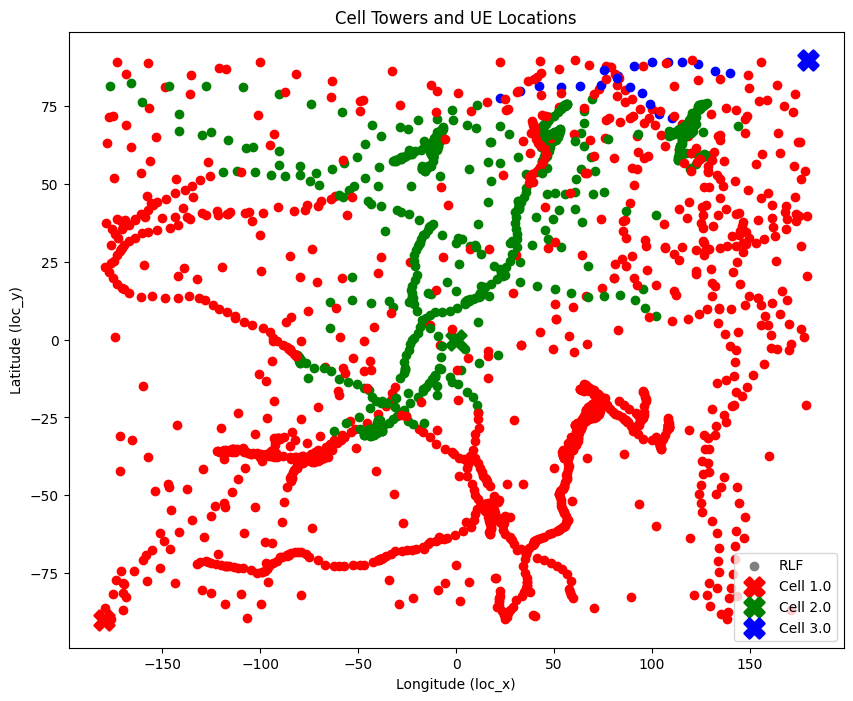

In [13]:
plots.plot_scatter2(attached_df, topology)

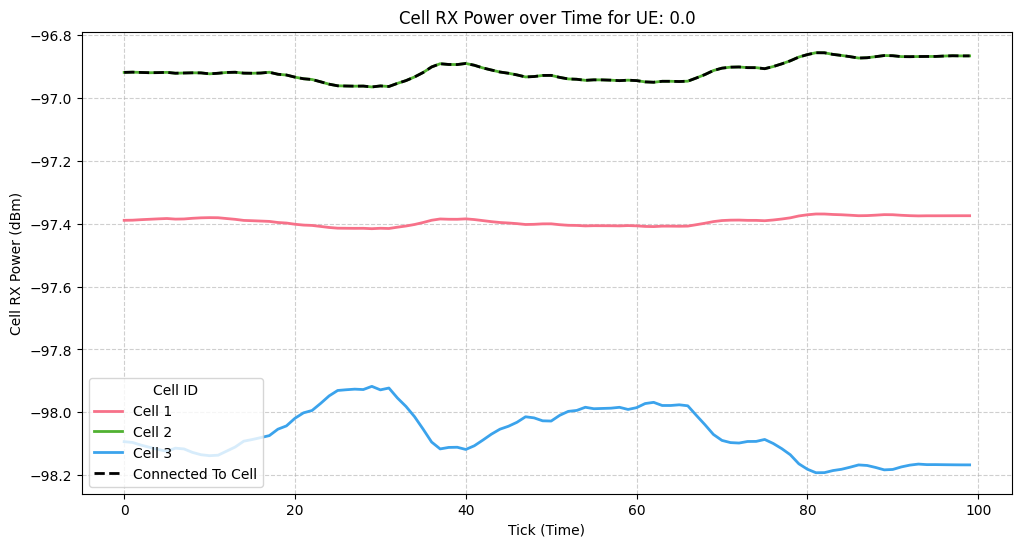

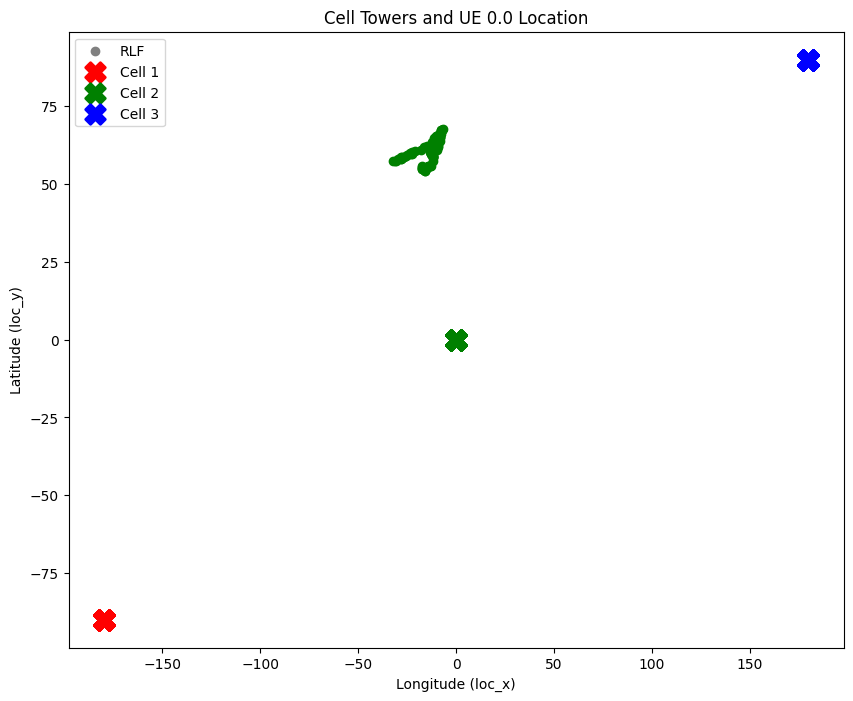

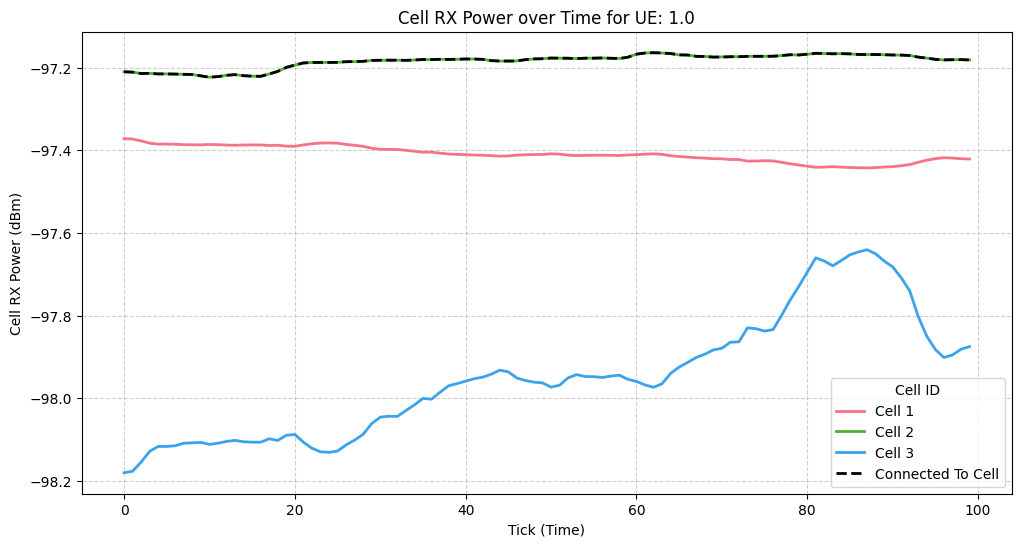

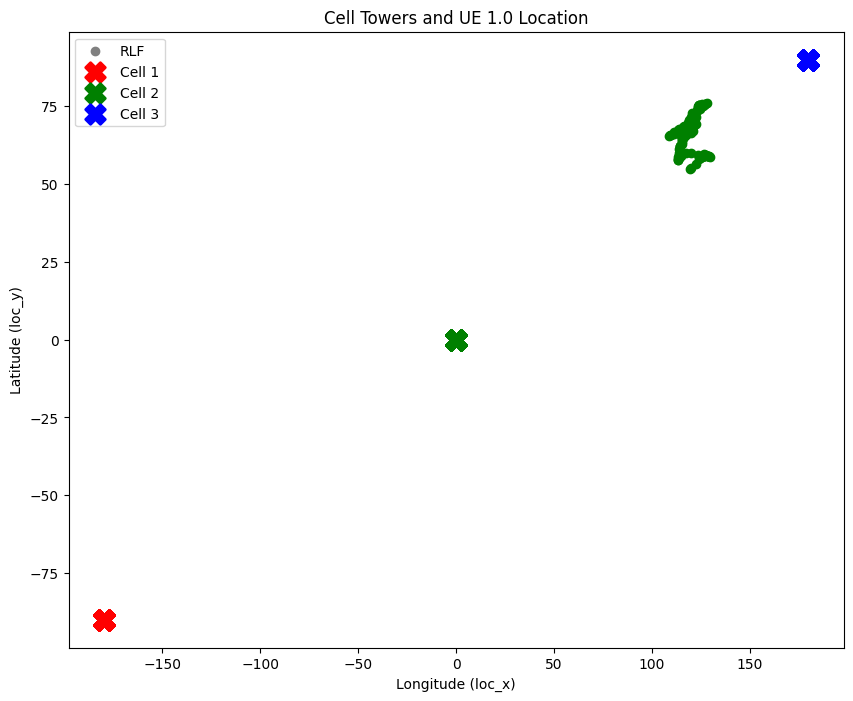

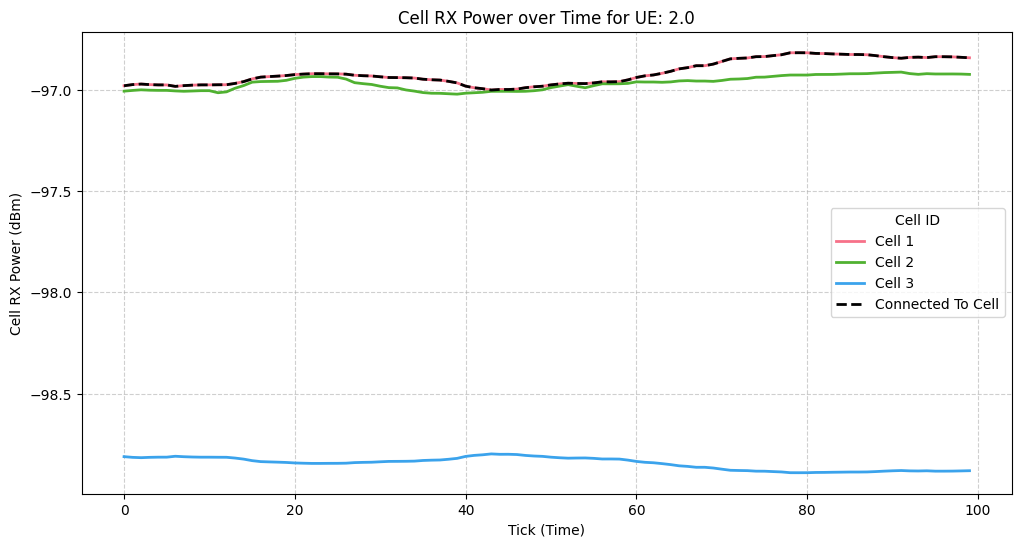

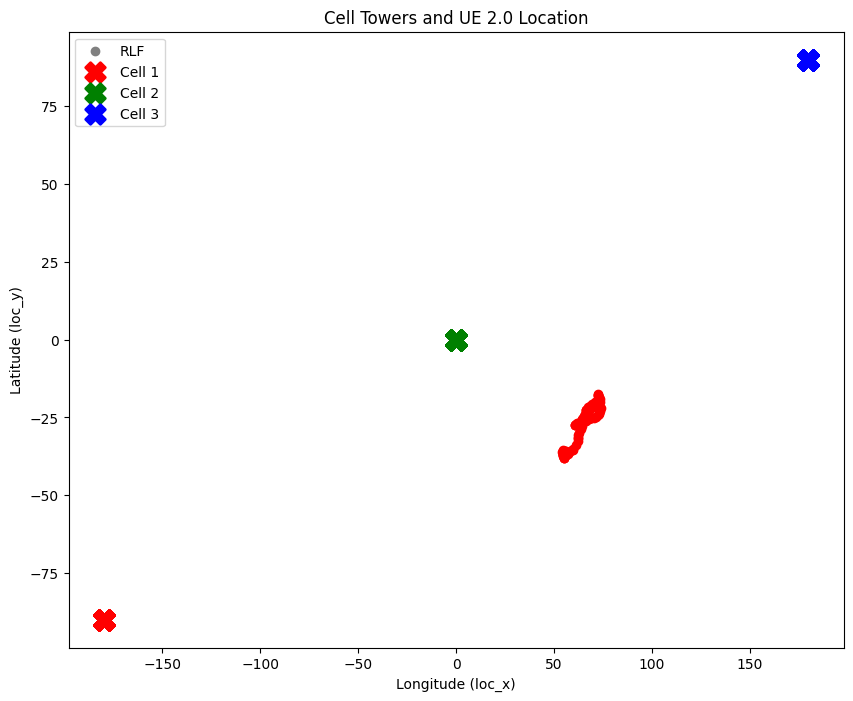

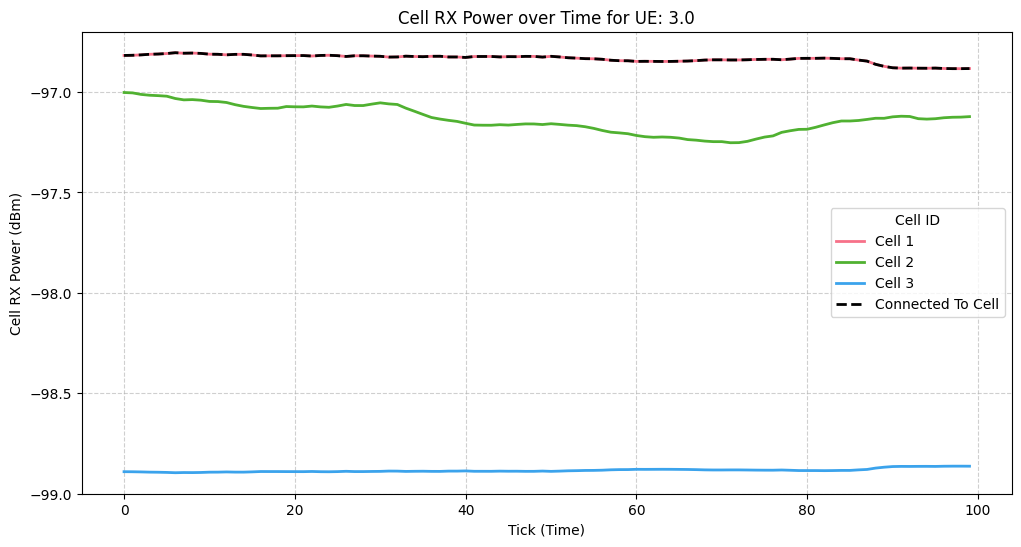

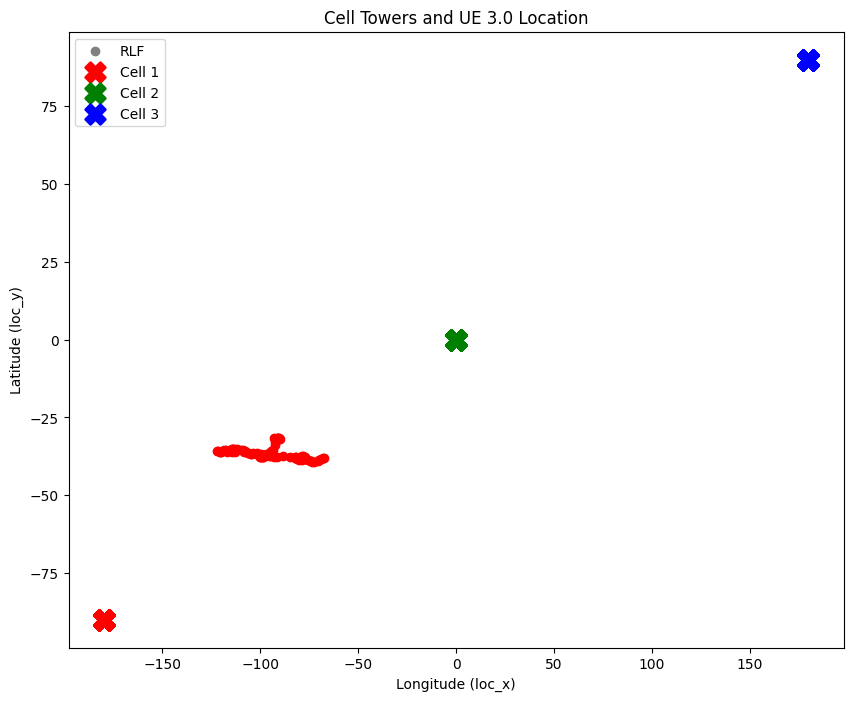

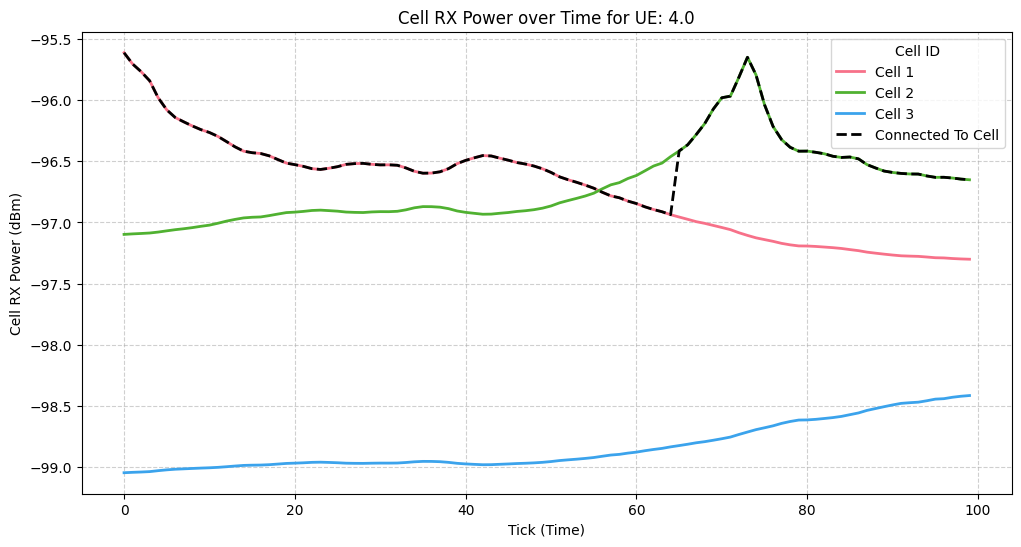

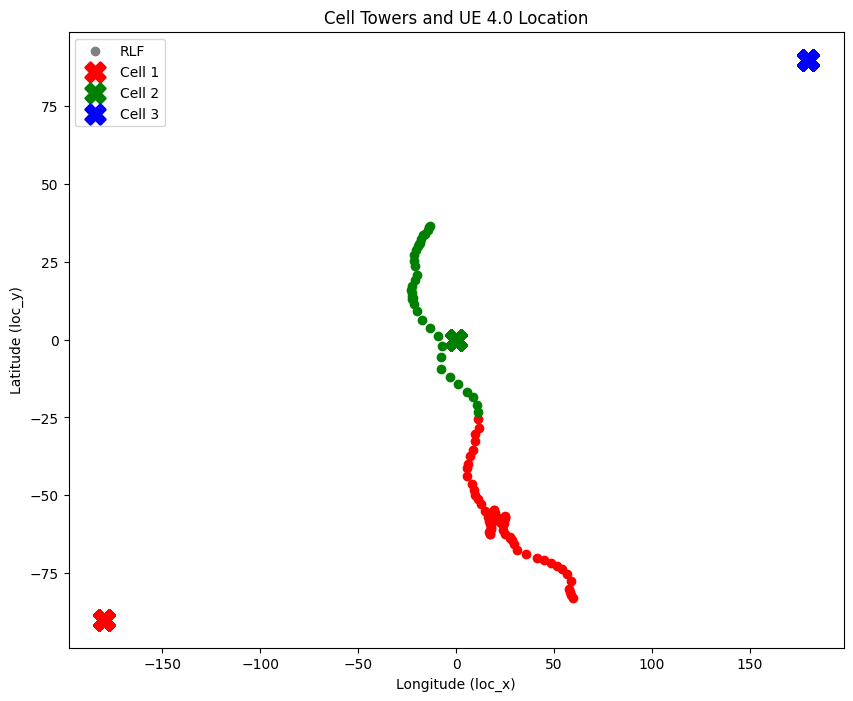

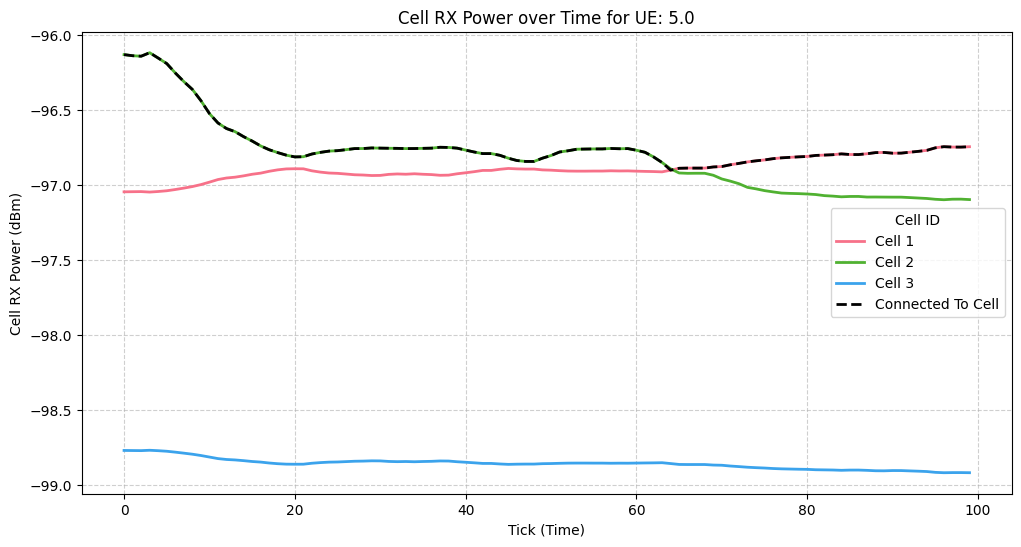

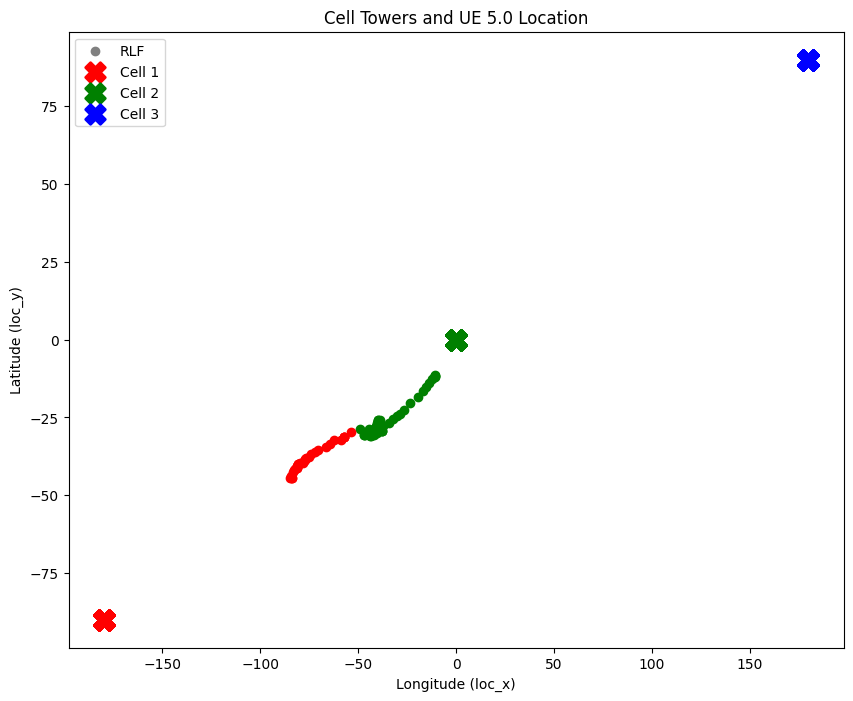

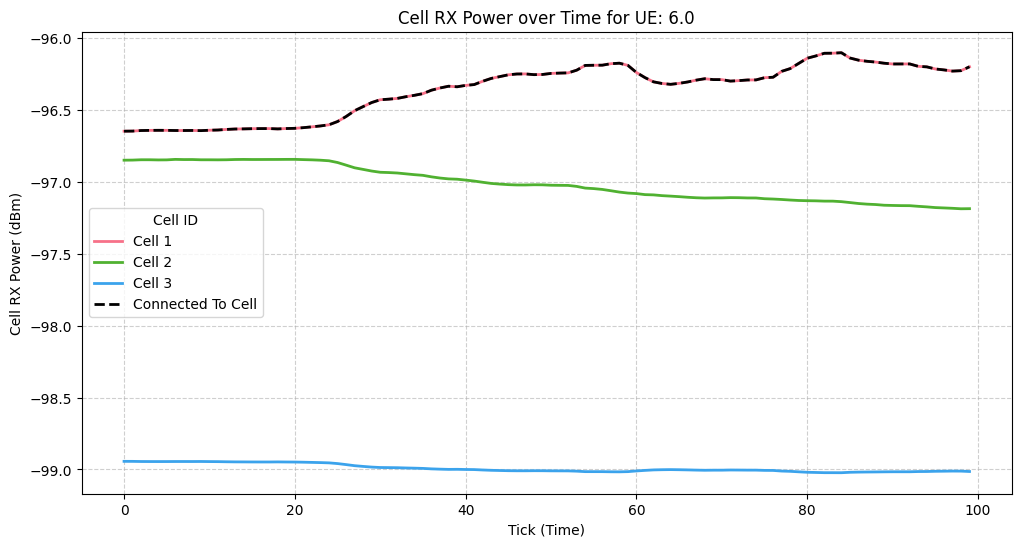

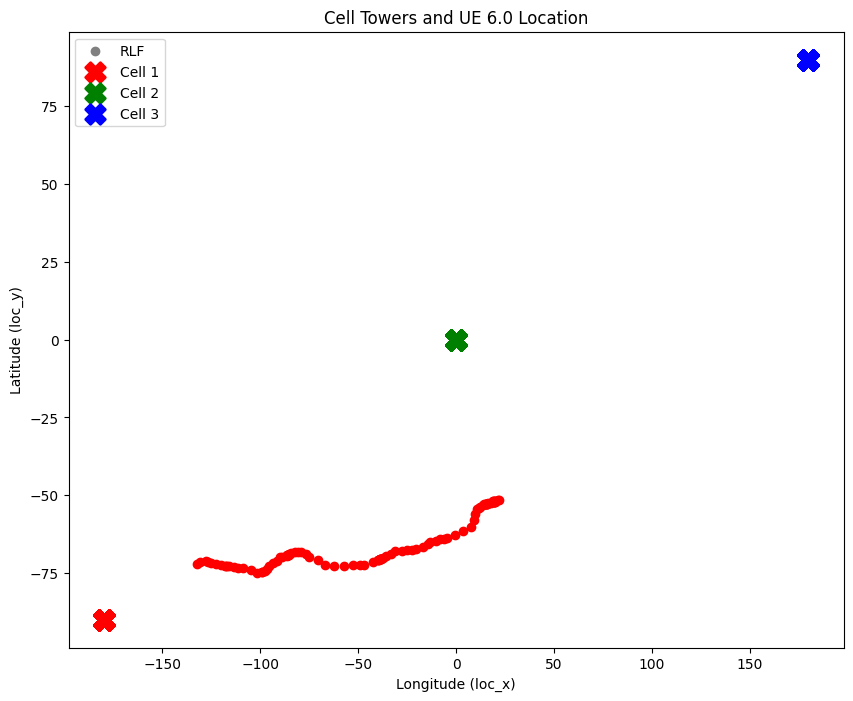

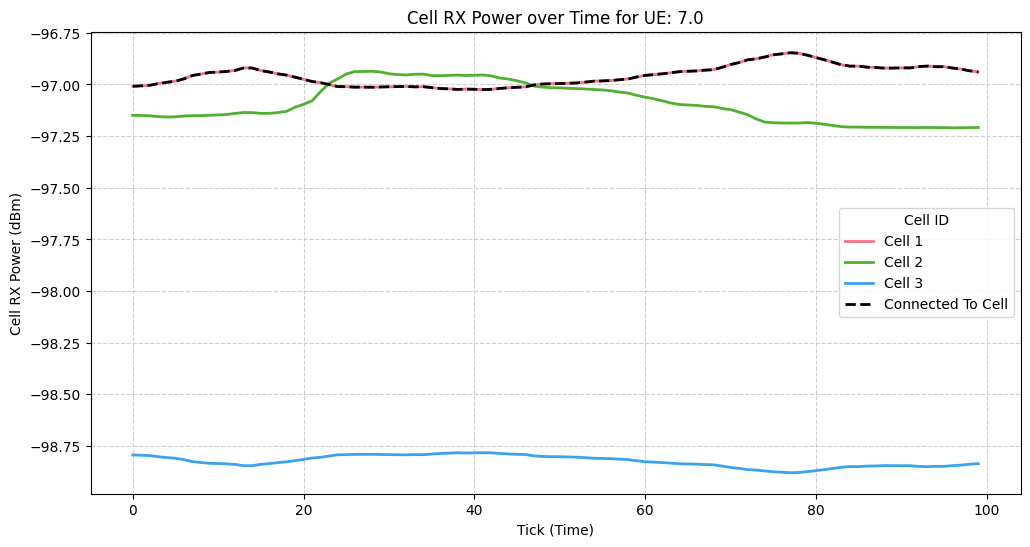

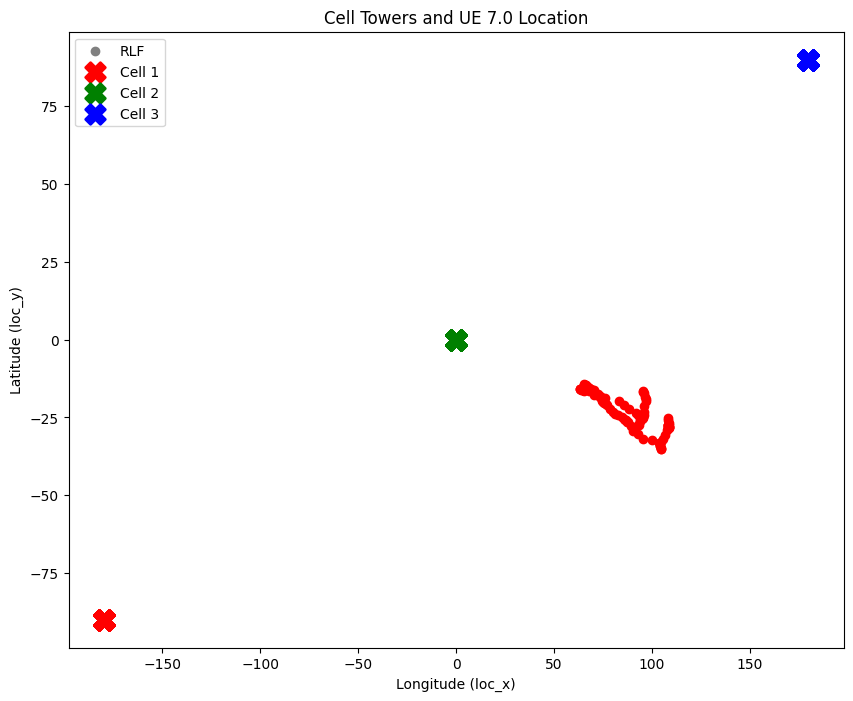

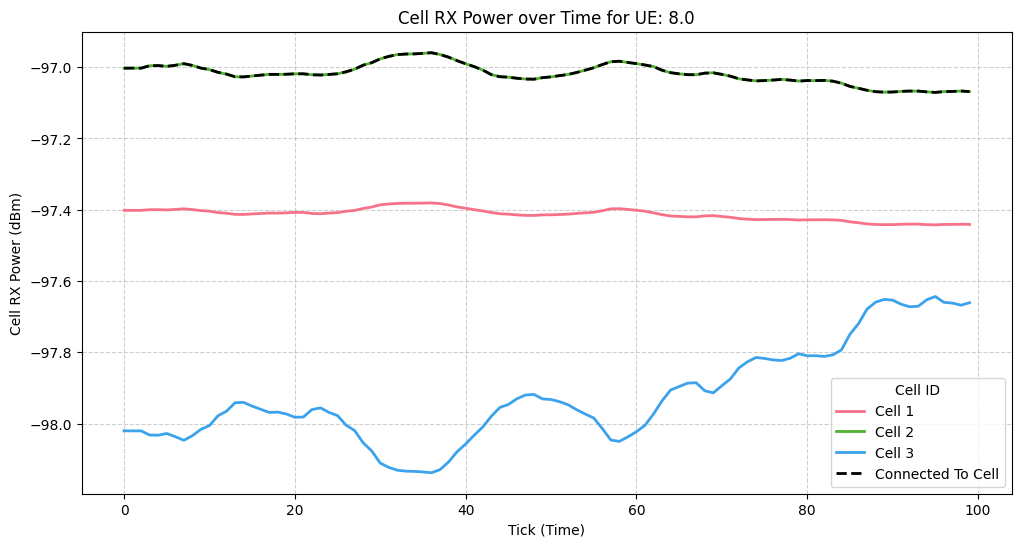

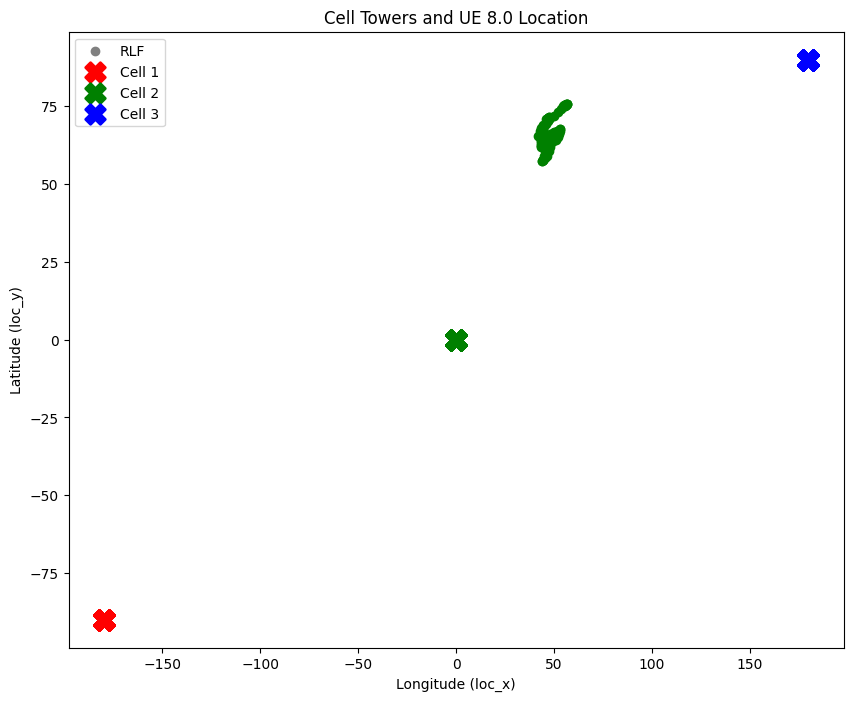

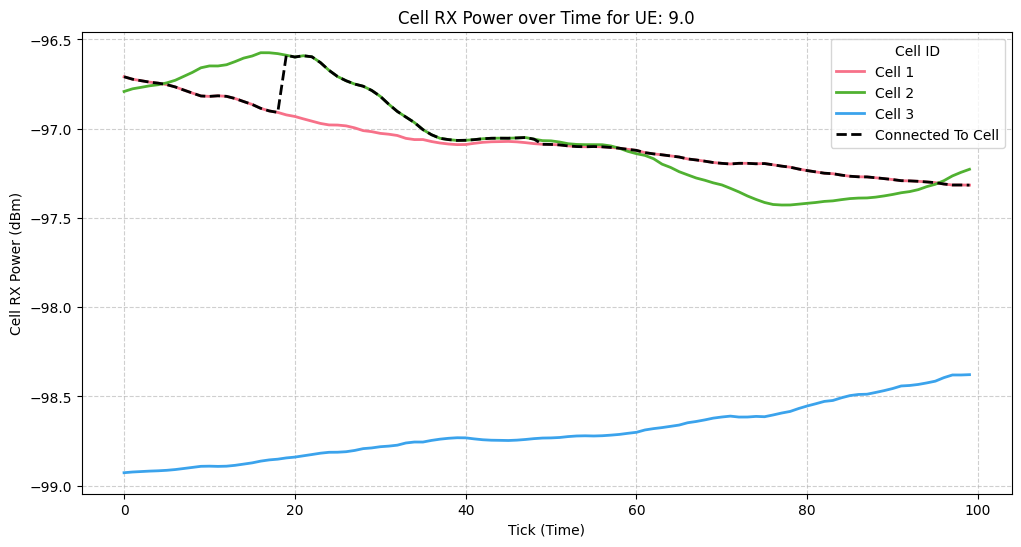

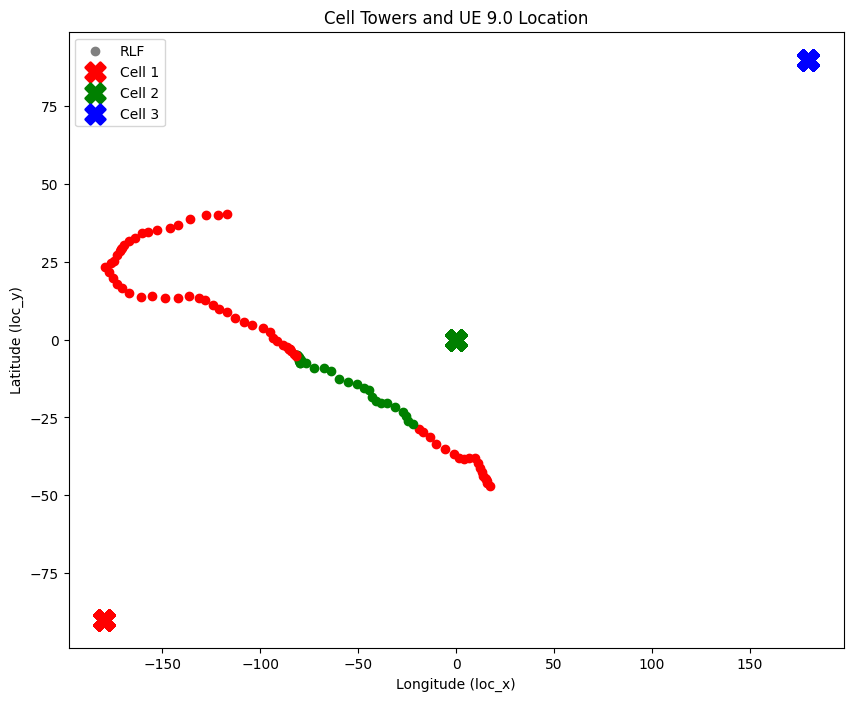

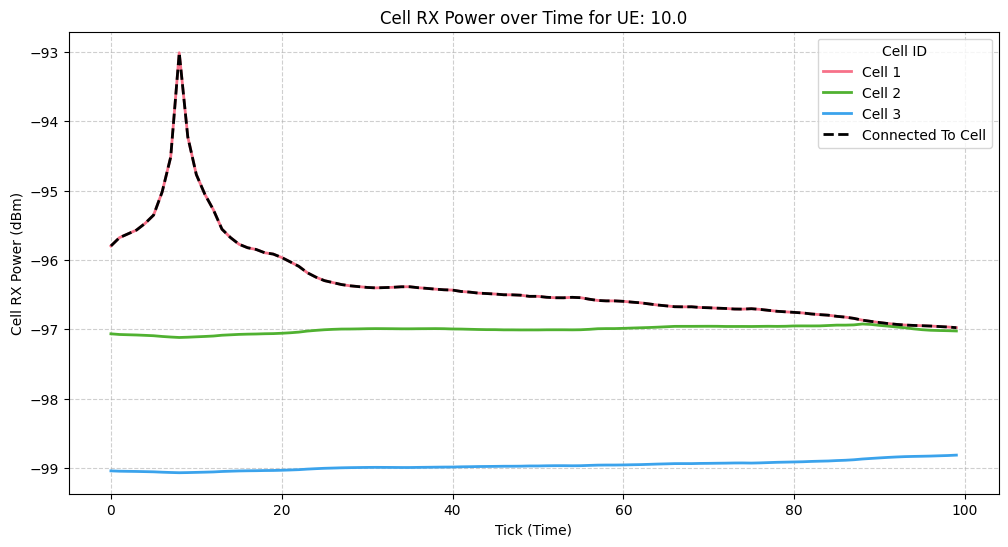

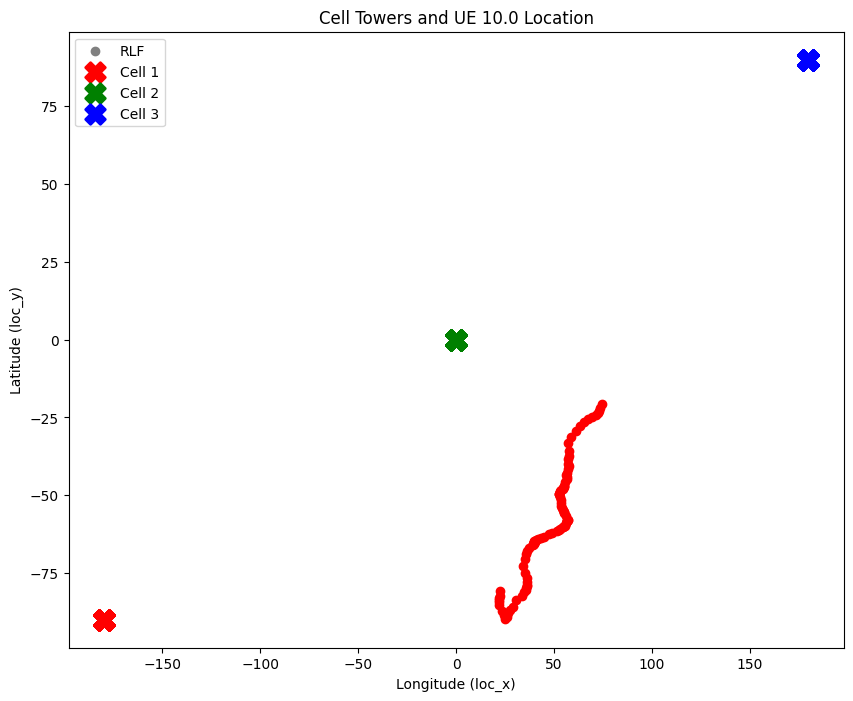

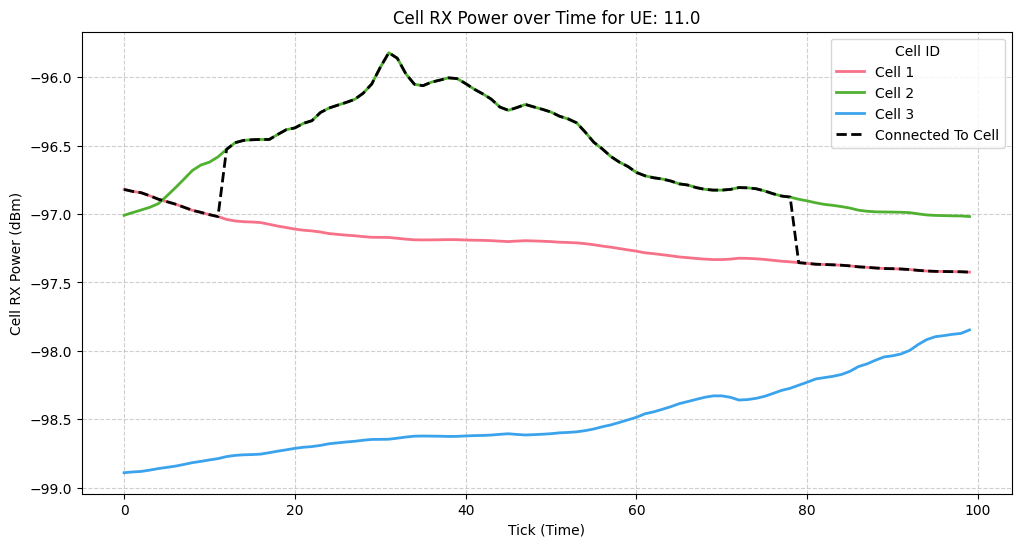

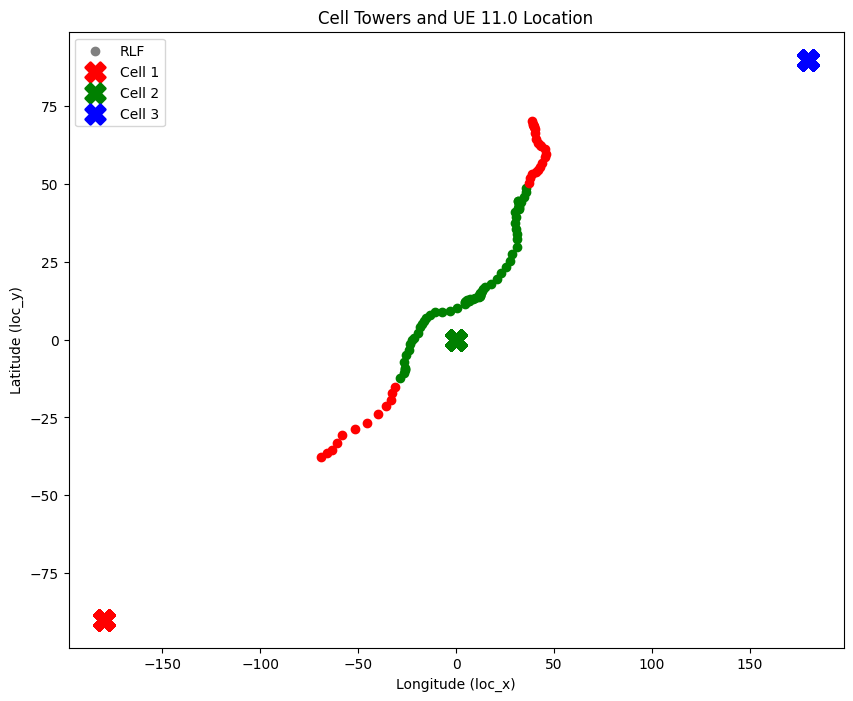

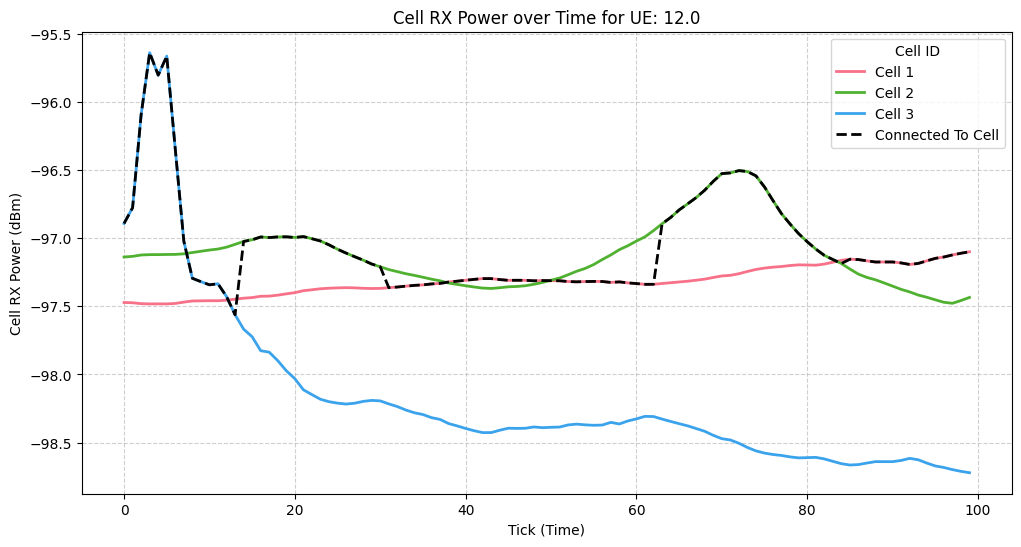

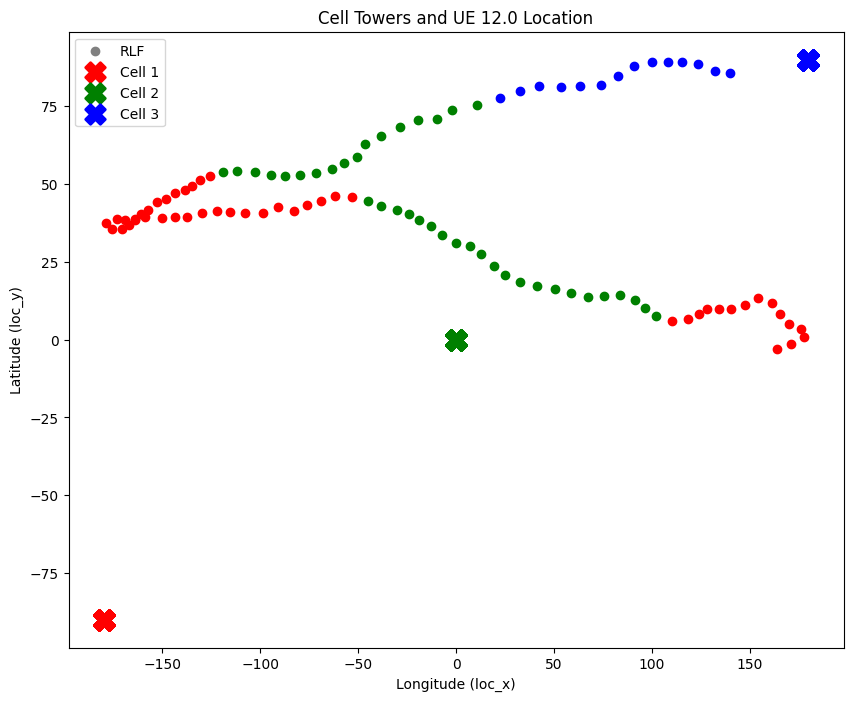

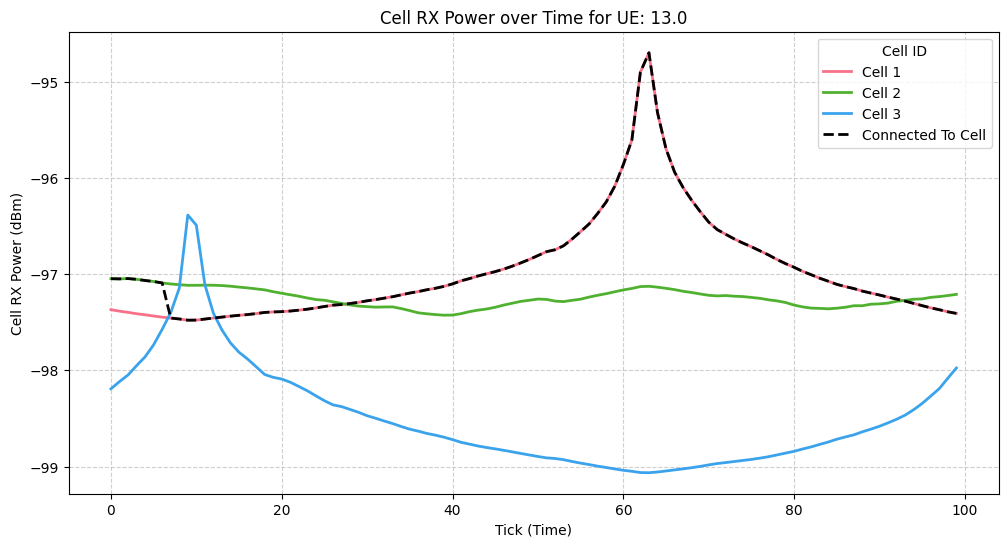

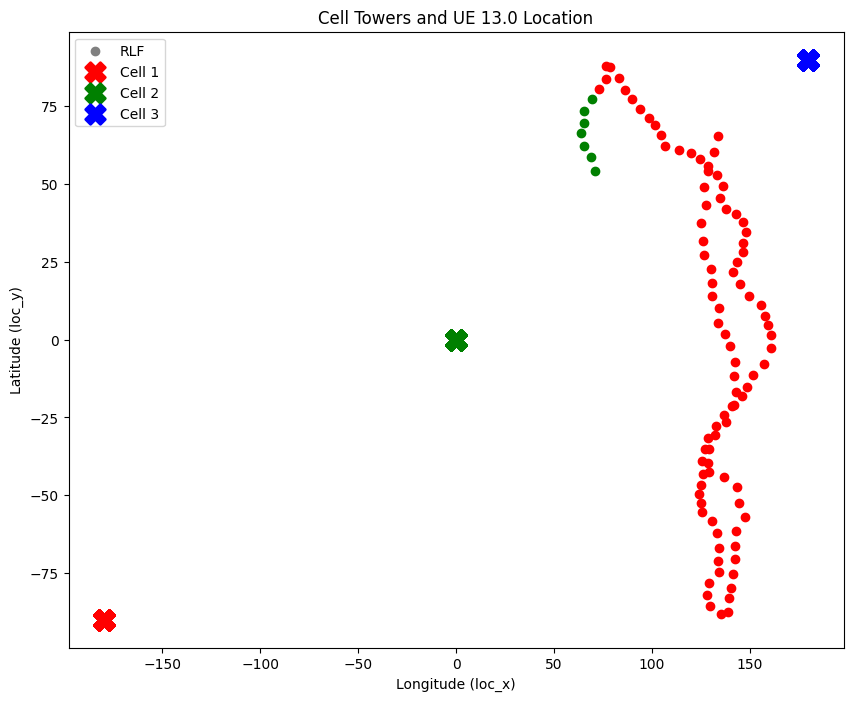

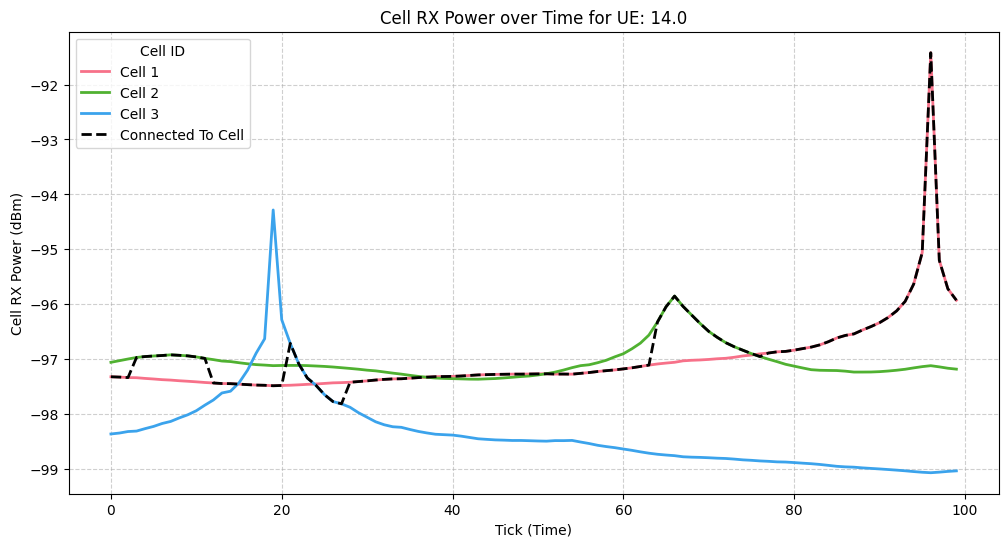

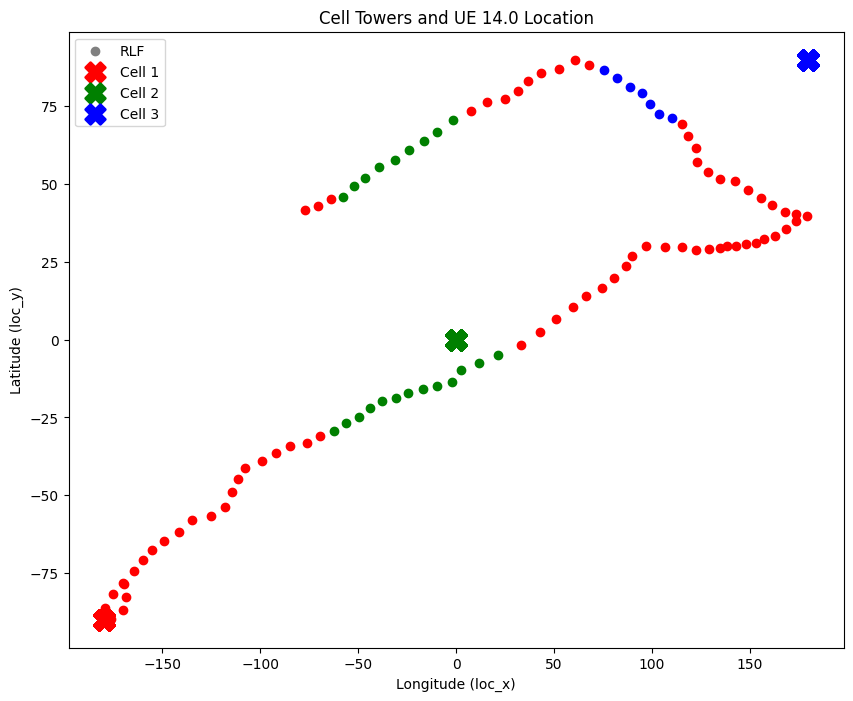

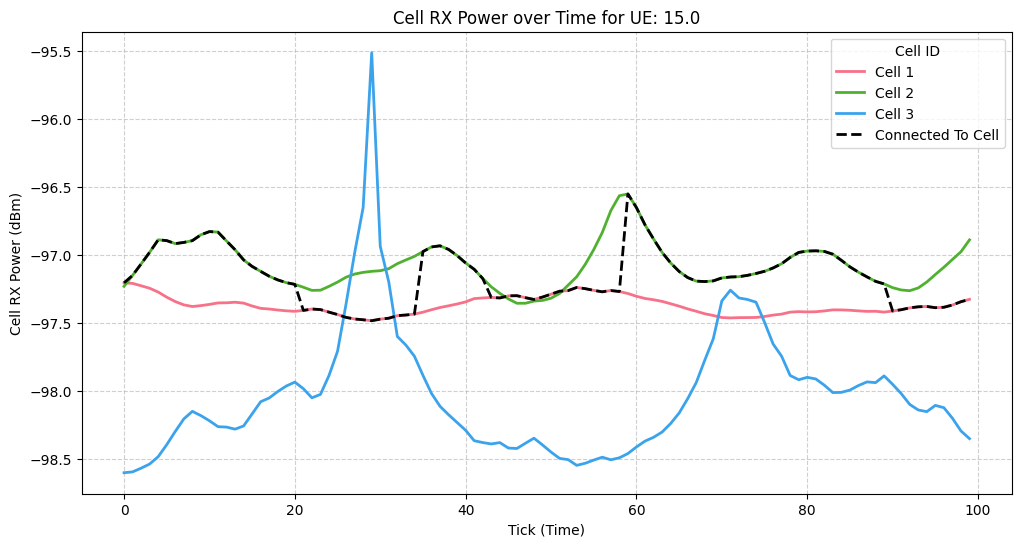

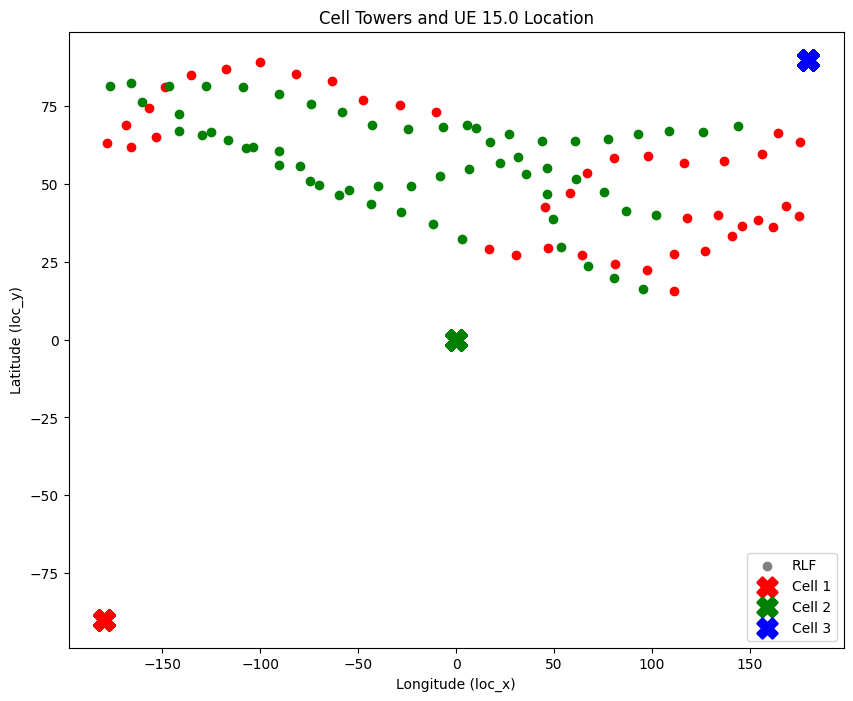

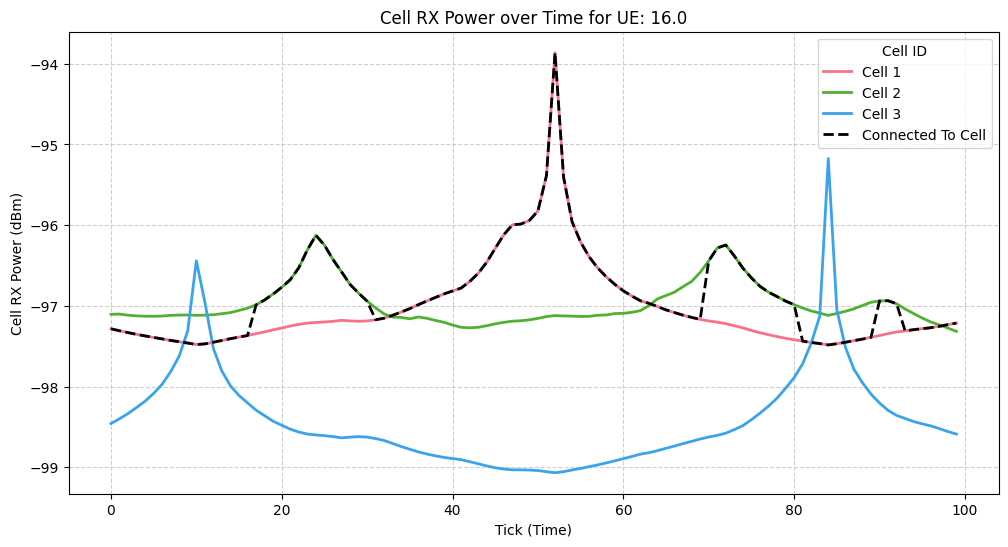

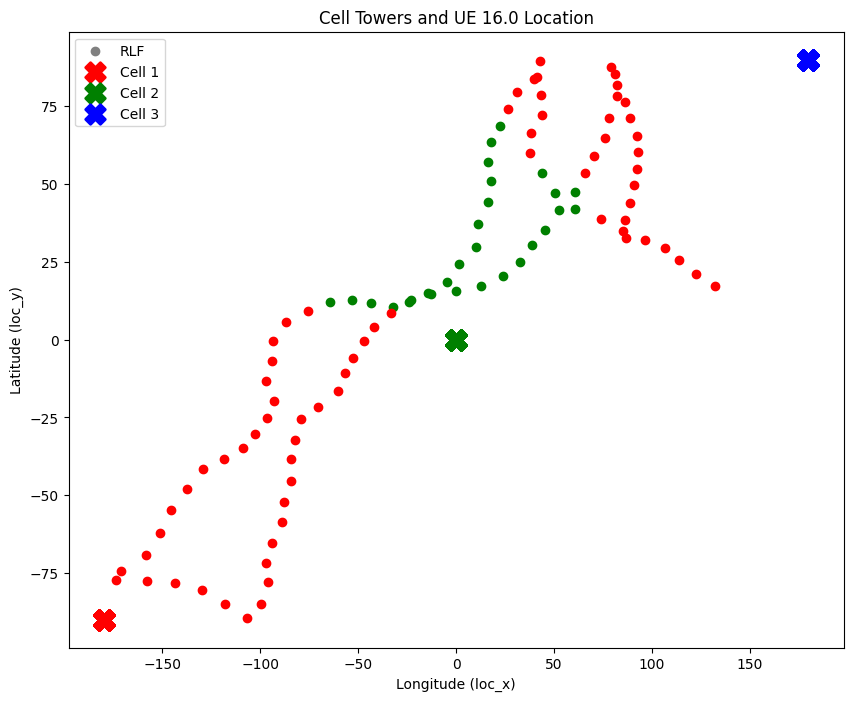

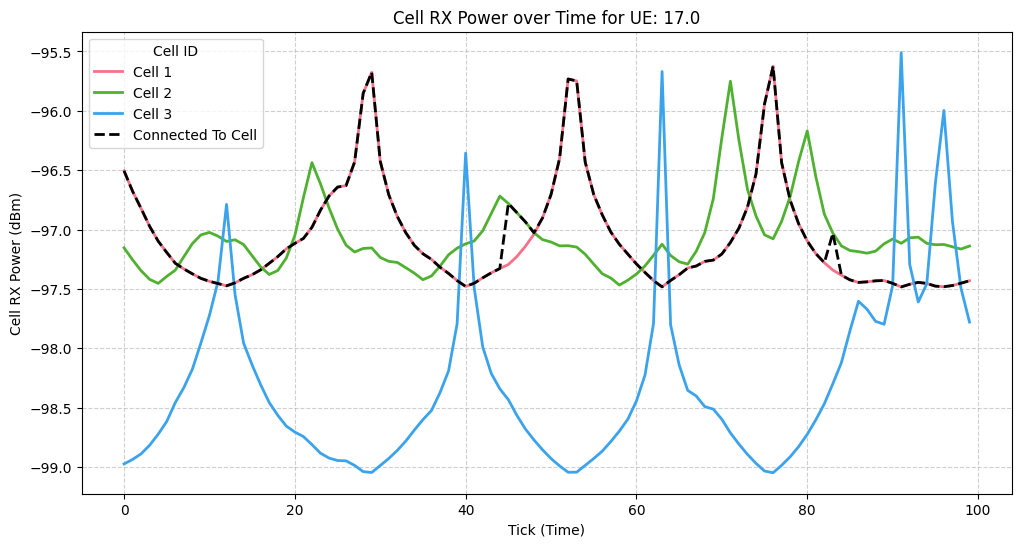

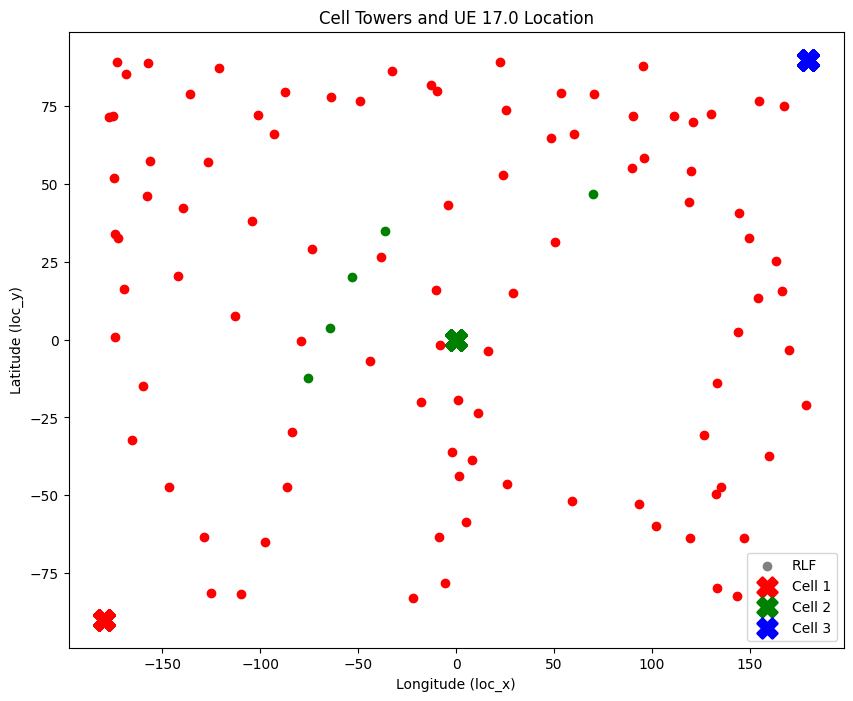

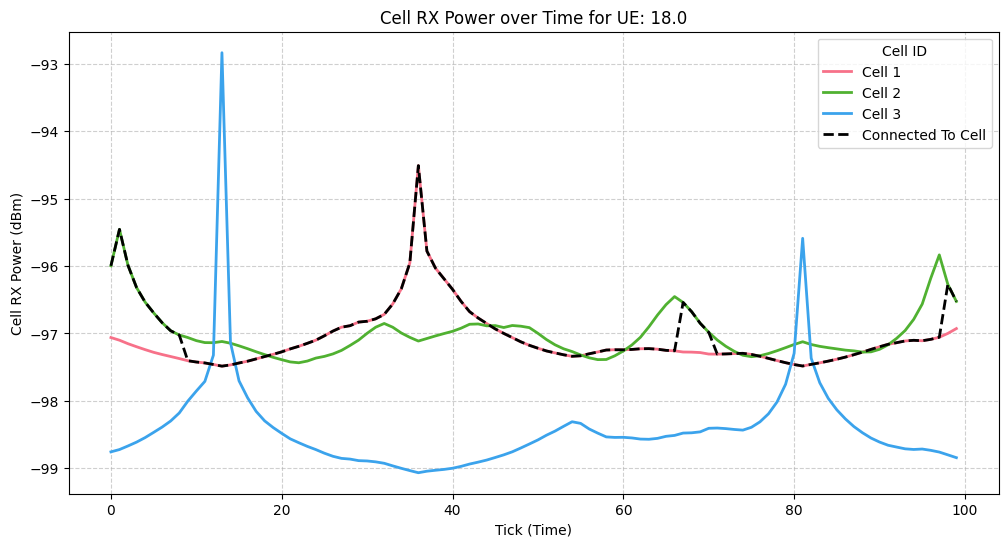

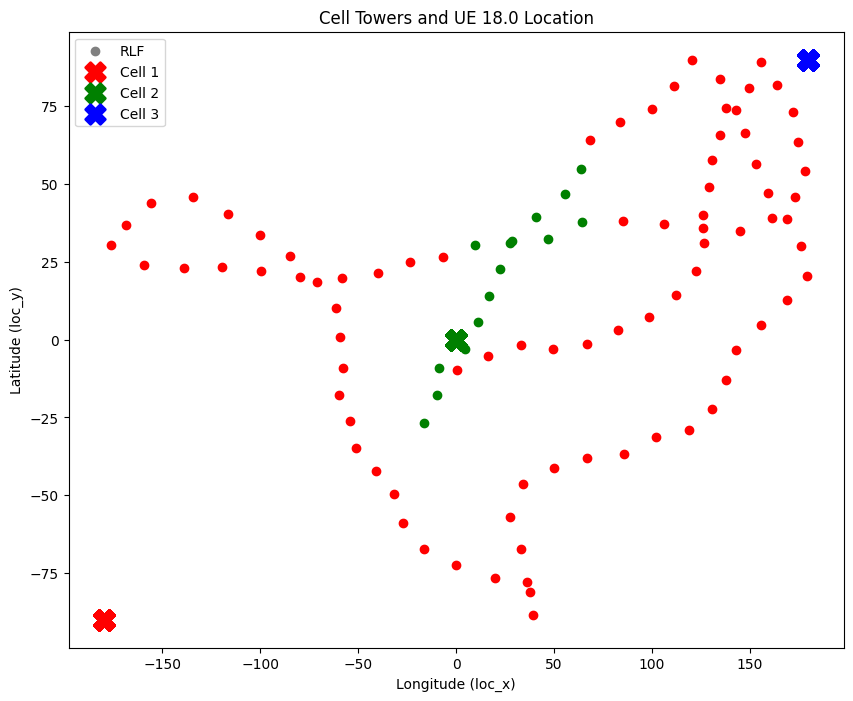

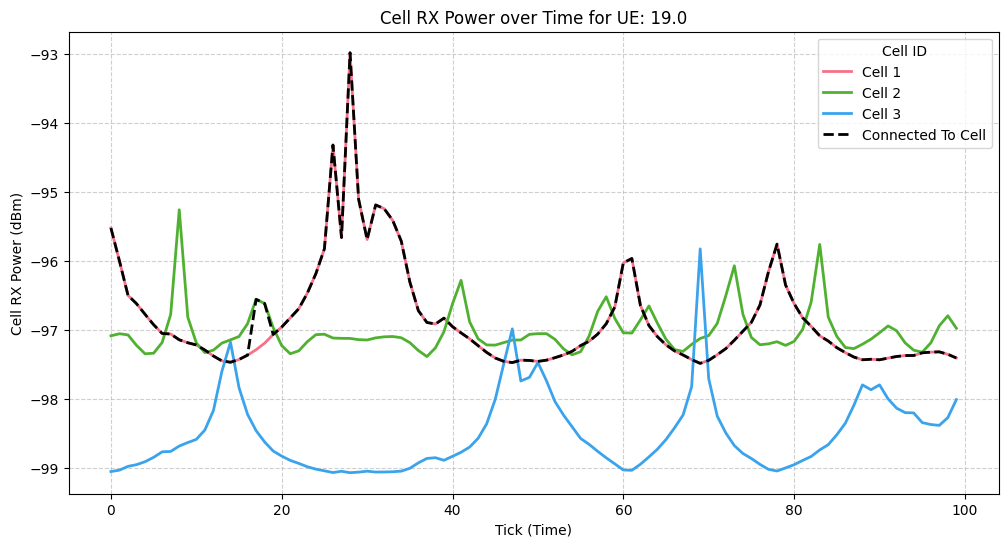

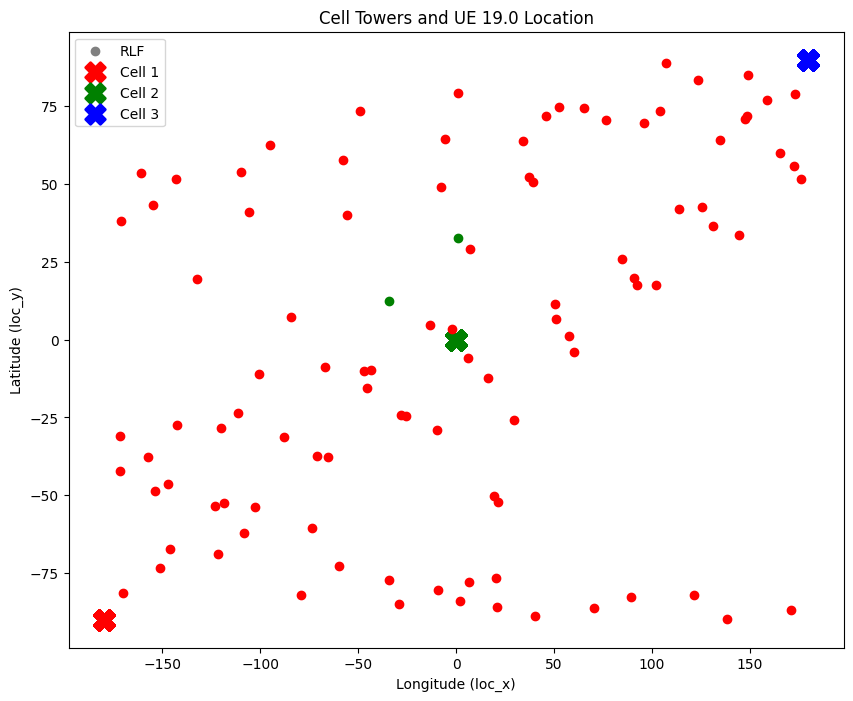

In [14]:
ue_ids = attached_df['ue_id'].unique()
for i in ue_ids:
    plots.plot_ue_rxpower_over_time(attached_df, data, i)
    plots.individual_scatter_plot(attached_df, data, i)

## Optimizing Hyst & TTT

In [15]:
max_diff = find_hyst_diff(attached_df)
num_ticks = attached_df["tick"].nunique()
print(f"Max Hyst Diff: {max_diff}\nNum Ticks: {num_ticks}")

Max Hyst Diff: 5.963597274371324
Num Ticks: 100


In [20]:
epochs = 500

hyst_range = [0, max_diff]
ttt_range = [2, num_ticks]
score = pd.DataFrame(columns=["hyst", "ttt", "score"])

In [21]:
print(f"{'Epoch':<6} {'Hyst':<14} {'TTT':<6} {'MRO Metric':<12}")
print("-" * 40)

for i in range(epochs):
    while True:
        hyst = np.random.uniform(hyst_range[0], hyst_range[1])
        ttt = np.random.randint(ttt_range[0], ttt_range[1])
        if ttt not in score["ttt"].values or hyst not in score["hyst"].values:
            break

    attached_df = perform_attachment_hyst_ttt(data, hyst, ttt, rlf_threshold)
    mro_metric = calculate_mro_metric(attached_df)

    print(f"{i:<6} {hyst:<14.10f} {ttt:<6} {mro_metric:<12.6f}")
    score.loc[len(score)] = [hyst, ttt, mro_metric]

Epoch  Hyst           TTT    MRO Metric  
----------------------------------------
0      4.2018579519   79     96.450000   
1      0.9938695848   97     95.600000   
2      1.2727248970   99     95.600000   
3      1.6550801855   93     95.900000   
4      5.7802826163   49     97.650000   
5      0.2456010587   5      97.950000   
6      1.9039309763   69     96.750000   
7      1.7812577434   93     95.900000   
8      0.7782424378   45     97.800000   
9      5.4208933716   40     98.100000   
10     2.5427201193   63     97.150000   
11     1.4842490913   52     97.600000   
12     0.2039560652   12     98.450000   
13     4.8004133742   88     96.050000   
14     2.2093934295   83     96.300000   
15     1.1023677330   31     98.200000   
16     5.6721192480   89     96.050000   
17     0.7723231791   43     97.900000   
18     1.6204921921   31     98.200000   
19     2.9934852040   36     98.100000   
20     0.8328752428   84     96.150000   
21     1.4179439692   20     98.450

In [22]:
score.loc[score["score"].idxmax()]

hyst      4.87647
ttt       2.00000
score    99.85000
Name: 123, dtype: float64

In [23]:
plots.plot_3d_hyst_ttt_score(score)